# 02 · El modelo downstream: buscar una arquitectura válida y congelarla

## Por qué este notebook existe

El enunciado pide "buscar una arquitectura de red neuronal válida" para el problema. Pero hay una razón más
importante que el enunciado: **el modelo downstream es nuestro instrumento de medida**. Todo el trabajo consiste en
comparar su error con y sin datos sintéticos, así que si la arquitectura cambiara entre experimentos estaríamos
midiendo búsqueda de arquitecturas, no calidad de datos.

Por eso este notebook hace una sola cosa: elegir la arquitectura **sobre datos 100% reales**, y congelarla. A partir
de aquí no se vuelve a tocar.

## Dos decisiones de diseño que conviene justificar antes de ver números

**Métrica principal: PR-AUC.** Con un 5-13% de positivos, la *accuracy* es inútil (un modelo que diga siempre "no"
acierta el 90%) y el ROC-AUC es demasiado optimista, porque el enorme número de negativos hace que la tasa de falsos
positivos se mueva poco. La precisión-recall se centra en la clase rara, que es la que nos importa. Reportamos el
**lift** = PR-AUC / tasa base, para que el número sea interpretable: el azar da 1.

**Sin pesos de clase.** Podríamos reequilibrar con `class_weight`, y mejoraría. No lo hacemos a propósito:
reequilibrar la clase minoritaria es exactamente el trabajo que queremos que hagan los datos sintéticos. Si lo
hiciéramos también en la función de pérdida, estaríamos tapando el efecto que intentamos medir.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [2]:
from src import config, data, downstream, experiments, plots

split, returns, extras = data.load_problem()
print(f"Tasa base -> train {split.y_train.mean():.2%} | val {split.y_val.mean():.2%} | test {split.y_test.mean():.2%}")
print(f"Forma de entrada: {split.input_shape}")

Tasa base -> train 5.00% | val 13.28% | test 7.79%
Forma de entrada: (60, 23)


## Los modelos de referencia no son de paja

Antes de entrenar redes, hay que saber contra qué competimos. Dos predictores de una línea:

- **Volatilidad realizada** de la ventana. La volatilidad se agrupa, así que "últimamente ha habido turbulencia" ya
  es una predicción decente de turbulencia futura. Es el modelo mental de cualquier gestor de riesgo.
- **Drawdown actual** respecto al máximo de la ventana.

Y un modelo lineal: **regresión logística** sobre la ventana aplanada, que ocupa el hueco del "modelo lineal" en la
comparativa del profesor.

Cualquier red que no supere a estos tres no está aprendiendo nada que no supiéramos ya.

## Las variantes de CNN, y el error que nos costó dos intentos

Partimos del esqueleto convolucional de su mejor regresor (`CNN 2`: tres bloques `Conv1D` + `MaxPooling`, luego una
cabeza densa), con salida sigmoide y dropout porque nuestros conjuntos de entrenamiento bajan hasta 500 ventanas.

Las variantes comparadas son:

- `cnn_prof`: su arquitectura literal, con `padding="valid"`.
- `cnn_raw`: igual pero con `padding="same"`.
- `cnn_mag`: añade `|r|` como canales extra.
- `cnn_mag_bn`: con `BatchNormalization`.
- `cnn_mag_gap`: con `GlobalAveragePooling` en vez de `Flatten`.

**Por qué `|r|`.** Nuestra primera CNN perdía contra el baseline de volatilidad (PR-AUC 0.39 frente a 0.45). La razón
no es la capacidad: una capa convolucional calcula `Wx + b` seguido de un ReLU, y eso es una operación de **primer
orden**. Puede sumar, restar y umbralizar sus entradas, pero **no puede multiplicar dos de ellas**, así que no puede
calcular una varianza. Le estábamos pidiendo a la red que midiera volatilidad con una herramienta estructuralmente
incapaz de hacerlo.

Concatenar `|r|` a la entrada cuesta **cero parámetros**, no aprende nada (así que no puede sobreajustar ni filtrar
información) y, lo más importante, **mantiene la entrada del modelo como una ventana de retornos crudos**. Eso es
esencial: todos los generadores producen ventanas de retornos, así que siguen siendo directamente comparables por
mucho que la red haga transformaciones internas.

Esta misma idea reaparece dos veces más en el proyecto (en el discriminador de la GAN y en el modelo
autorregresivo). Está documentada en `src/layers.py`.

In [3]:
tabla, historias = experiments.model_selection_table(split)
cols = ["val_pr_auc", "val_lift", "test_pr_auc", "test_lift", "test_roc_auc", "test_recall", "test_precision"]
display(tabla[cols].round(3))

,val_pr_auc,val_lift,test_pr_auc,test_lift,test_roc_auc,test_recall,test_precision
Baseline: vol. realizada,0.685,5.159,0.453,5.811,0.756,0.361,0.595
Baseline: drawdown actual,0.645,4.861,0.492,6.320,0.754,0.454,0.430
Regresión logística,0.416,3.132,0.282,3.617,0.633,0.279,0.295
CNN cnn_prof,0.666,5.014,0.399,5.121,0.707,0.284,0.722
CNN cnn_raw,0.719,5.418,0.520,6.678,0.819,0.366,0.615
CNN cnn_mag,0.726,5.470,0.518,6.652,0.830,0.426,0.467
CNN cnn_mag_bn,0.686,5.164,0.491,6.302,0.784,0.486,0.344
CNN cnn_mag_gap,0.702,5.288,0.452,5.806,0.768,0.339,0.590


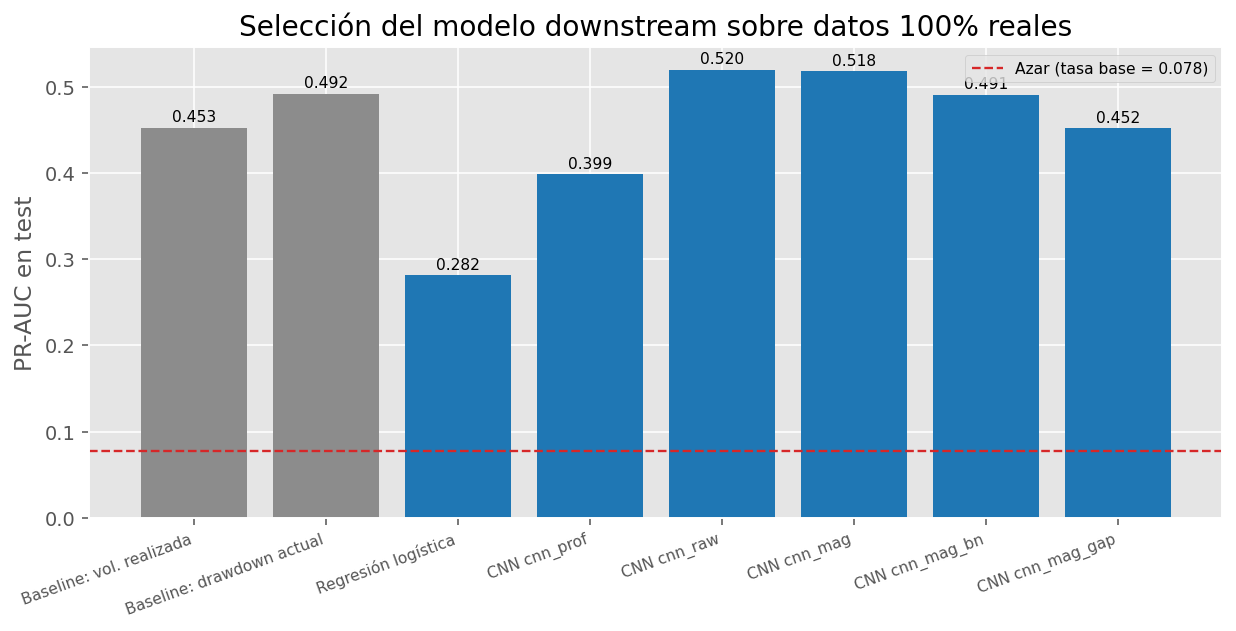

In [4]:
fig = plots.plot_model_comparison(tabla, metric="test_pr_auc", baseline_rate=float(split.y_test.mean()))
display(Image(str(fig)))

## Curvas de loss de la selección

El enunciado exige curvas de convergencia de **todos** los entrenamientos. Aquí están las de las variantes de CNN;
las de los generadores están en el notebook 03 y las de las ~375 celdas del barrido se guardan una a una en
`results/histories/`.

Lo que hay que mirar: `val_pr_auc` sube y se estanca, y el *early stopping* restaura los mejores pesos. La
divergencia entre `loss` y `val_loss` es la esperada con 567 positivos y una red de este tamaño; por eso paramos
por PR-AUC de validación y no por la pérdida de entrenamiento.

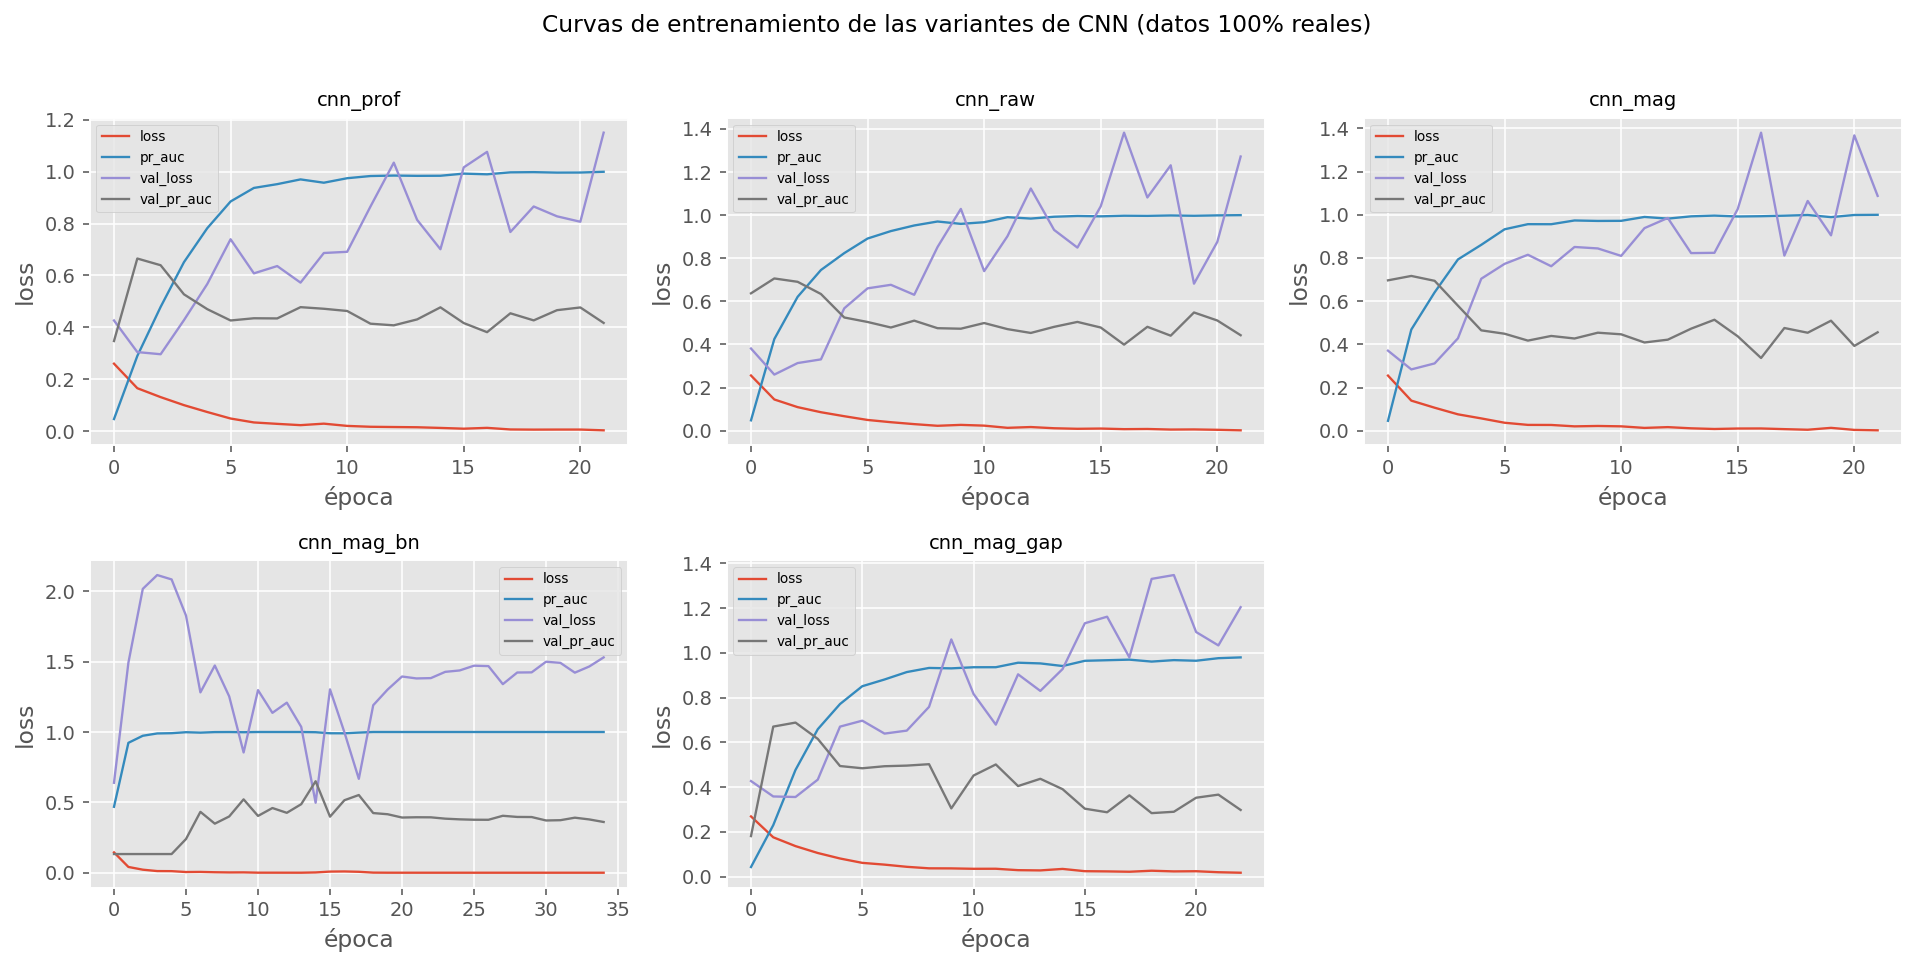

In [5]:
fig = plots.plot_loss_curves(
    historias, name="02_curvas_downstream",
    title="Curvas de entrenamiento de las variantes de CNN (datos 100% reales)",
)
display(Image(str(fig)))

## Arquitectura congelada

Elegimos **`cnn_mag`** y no se vuelve a tocar en todo el proyecto (`config.DOWNSTREAM_VARIANT`).

Honestamente: `cnn_raw` y `cnn_mag` quedan **empatadas en PR-AUC** dentro del ruido experimental. Nos quedamos con
`cnn_mag` por dos motivos, ninguno de los cuales es "gana por más margen": tiene mejor ROC-AUC y mejor recall, y
tiene una **justificación estructural** (le da a la red acceso al segundo momento, que es la magnitud de la que
depende la etiqueta) en lugar de ser el resultado de probar cinco cosas y quedarse con la mejor.

Lo que sí es un resultado claro es el orden: **CNN > baselines financieros > regresión logística**. La red aporta
sobre el conocimiento experto, y el problema no es linealmente separable.

In [6]:
modelo = downstream.build_classifier(split.input_shape, variant=config.DOWNSTREAM_VARIANT)
modelo.summary()
print(f"\nArquitectura congelada: {config.DOWNSTREAM_VARIANT}")
print(f"Épocas máximas: {config.DOWNSTREAM_EPOCHS} | batch: {config.DOWNSTREAM_BATCH} | paciencia: {config.DOWNSTREAM_PATIENCE}")

Model: "stress_cnn_mag"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ magnitude_features              │ (None, 60, 46)         │             0 │
│ (MagnitudeFeatures)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 64)         │         8,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        89,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,681 (674.54 KB)

 Trainable params: 172,681 (674.54 KB)

 Non-trainable params: 0 (0.00 B)


Arquitectura congelada: cnn_mag
Épocas máximas: 120 | batch: 128 | paciencia: 20
